In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

In [2]:
np.random.seed(0)
X, y=make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, random_state=0
)

In [3]:
def fit_naive_bayes(X, y):
    classes=np.unique(y)
    stats={}
    priors={}
    for c in classes:
        X_c=X[y==c]
        stats[c]=(X_c.mean(axis=0), X_c.std(axis=0))
        priors[c]=len(X_c)/len(X)
    return stats, priors

In [9]:
def gaussian_pdf(X, mean, std):
    eps=1e-9
    coeff=1/(np.sqrt(2*np.pi)*(std+eps))
    exponent=np.exp(-((X-mean)**2)/(2*(std+ eps)**2))
    return coeff*exponent

In [10]:
def predict_naive_bayes(X_test, stats, priors):
    predictions=[]
    for x in X_test:
        class_probs={}
        for c in stats:
            mean, std=stats[c]
            likelihood=np.prod(gaussian_pdf(x, mean, std))
            class_probs[c]=likelihood*priors[c]
        predictions.append(max(class_probs, key=class_probs.get))
    return np.array(predictions)

In [11]:
def predict_proba_naive_bayes(X_test, stats, priors):
    probs=[]
    for x in X_test:
        class_scores={}
        for c in stats:
            mean, std=stats[c]
            likelihood=np.prod(gaussian_pdf(x, mean, std))
            class_scores[c]=likelihood*priors[c]
        total=sum(class_scores.values())
        probs.append(class_scores[1]/ total)
    return np.array(probs)

In [12]:
stats, priors=fit_naive_bayes(X, y)
preds=predict_naive_bayes(X, stats, priors)
y_scores=predict_proba_naive_bayes(X, stats, priors)

accuracy=(preds==y).mean()
print(f"My Naive Bayes accuracy: {accuracy:.4f}")

#sklearn comparison
sk_nb=GaussianNB().fit(X, y)
sk_preds=sk_nb.predict(X)
sk_accuracy=(sk_preds==y).mean()
print(f"sklearn GaussianNB accuracy: {sk_accuracy:.4f}")

My Naive Bayes accuracy: 0.8900
sklearn GaussianNB accuracy: 0.8900


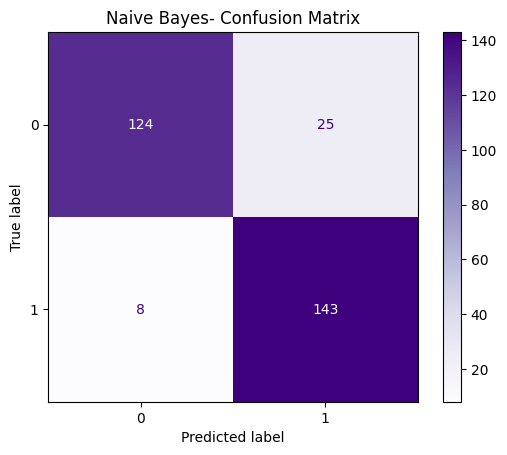

In [13]:
cm=confusion_matrix(y, preds)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title("Naive Bayes- Confusion Matrix")
plt.show()

In [14]:
precision=precision_score(y, preds)
recall=recall_score(y, preds)
f1=f1_score(y, preds)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.8512
Recall: 0.9470
F1 Score: 0.8966


ROC_AUC: 0.9517


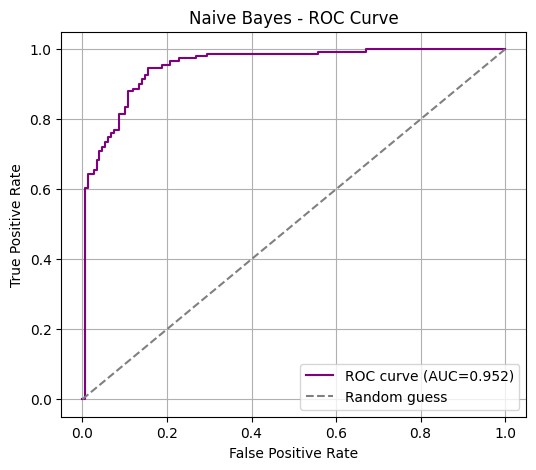

In [15]:
roc_auc=roc_auc_score(y, y_scores)
print(f"ROC_AUC: {roc_auc:.4f}")

fpr, tpr, _=roc_curve(y, y_scores)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="purple", label=f"ROC curve (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes - ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\5soum\AppData\Local\Temp\ipykernel_31800\547898710.py:10: UserWarning: The following kwargs were not used by contour: 'aplha'
  plt.contourf(xx, yy, grid_preds, aplha=0.2, cmap="PuOr")


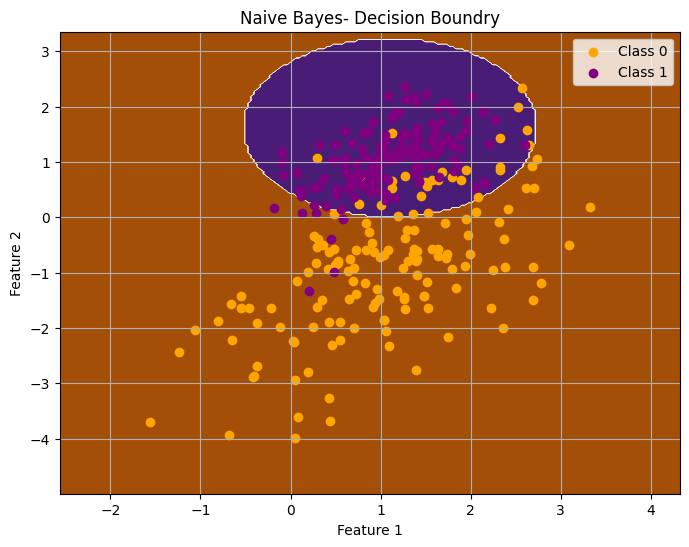

In [16]:
xx, yy=np.meshgrid(
    np.linspace(X[:, 0].min() -1, X[:, 0].max()+ 1, 200),
    np.linspace(X[:, 1].min() -1, X[:, 1].max()+ 1, 200)
)
grid=np.c_[xx.ravel(), yy.ravel()]
grid_preds=predict_naive_bayes(grid, stats, priors)
grid_preds=grid_preds.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, grid_preds, aplha=0.2, cmap="PuOr")
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color="orange", label="Class 0")
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color="purple", label="Class 1")
plt.title("Naive Bayes- Decision Boundry")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Summary — Gaussian Naive Bayes (from scratch)

### What it does
Classifies using Bayes' Theorem: `P(class | features) ∝ P(features | class) × P(class)`. The "naive" part assumes features are independent given the class, so the joint likelihood becomes a simple product of per-feature probabilities. For continuous features, each feature's likelihood is modeled as a Gaussian (mean/std computed per class during training) — no gradient descent needed, just direct calculation.

### Results (synthetic 2D data, same as logistic regression session)
| Metric | Value |
|---|---|
| My accuracy | 0.8900 |
| sklearn accuracy | 0.8900 (exact match) |
| Precision | 0.8512 |
| Recall | 0.9470 |
| F1 | 0.8966 |
| ROC-AUC | 0.9517 |

Exact match with sklearn confirms the implementation is correct — unlike logistic regression, there's no regularization hyperparameter to cause divergence here since NB training is a direct closed-form calculation (means, stds, priors), not an iterative optimization.

### Confusion matrix insight
124 TN, 143 TP, 25 FP, 8 FN — more false positives than false negatives, explaining why recall (0.947) is higher than precision (0.851): the model catches almost all actual Class 1 samples but also mislabels some Class 0 samples as Class 1.

### Key takeaway — decision boundary shape
Naive Bayes' decision boundary came out as a **curved/closed region**, unlike logistic regression's **straight line** on the same data. This is a direct consequence of the Gaussian assumption — each class is modeled as its own bell-curve "blob," so the boundary between blobs is naturally curved. Different algorithms encode different assumptions about class shape in feature space, and that shows up directly in the boundaries they draw, not just in accuracy.

### Next: Categorical Naive Bayes
Gaussian NB only works for continuous features. For categorical features (e.g. Outlook, Windy in a Play Golf dataset), the likelihood is computed via frequency counts instead of a Gaussian PDF — planned as the next variant to implement.